In [10]:
import pandas as pd
from canexao import connect_to_mongo


collection_users, collection_tasks = connect_to_mongo()
tabela_users = pd.DataFrame(list(collection_users.find()))
tabela = pd.DataFrame(list(collection_tasks.find()))

Conexão estabelecida com sucesso!


In [11]:
tabela.head()

,_id,task_id,titulo,descricao,prioridade,user_id,mentorado,area_atuacao,mentor_responsavel,data_criacao,data_inicio,status_atual,data_conclusao,feedback_conclusao_mentorado,createdAt,updatedAt,__v
0,6a2b884993a2aac46c8ba14a,1.0,Otimizar Microsserviços - Sprint 8,Atividade focada em otimizar o recurso de micr...,media,6a2b8445cf36b576d237ae6b,Bruno Costa,DevBack-end,Juliana Costa,2026-05-05,2026-05-07,andamento,NaT,NaN,NaT,NaT,NaN
1,6a2b884993a2aac46c8ba14b,2.0,Testar Scripts de Deploy - Sprint 2,Atividade focada em testar o recurso de script...,alta,6a2b8468cf36b576d237ae6c,Felipe Andrade,QA,Juliana Costa,2026-03-25,2026-03-27,concluida,2026-04-02,Os testes cobriram os cenários críticos de aut...,NaT,NaT,NaN
2,6a2b884993a2aac46c8ba14c,3.0,Testar Cache em Redis - Sprint 2,Atividade focada em testar o recurso de cache ...,media,6a2b8468cf36b576d237ae6c,Felipe Andrade,QA,Juliana Costa,2026-03-26,2026-03-27,concluida,2026-04-06,Validação executada com sucesso. O fluxo corre...,NaT,NaT,NaN
3,6a2b884993a2aac46c8ba14d,4.0,Testar Componentes React - Sprint 8,Atividade focada em testar o recurso de compon...,media,6a2b8496cf36b576d237ae6d,Diego Martins,QA,Juliana Costa,2026-04-20,2026-04-21,concluida,2026-04-27,Conseguimos manter uma boa cobertura de testes...,NaT,NaT,NaN
4,6a2b884993a2aac46c8ba14e,5.0,Ajustar Exportação de Relatórios - Sprint 3,Atividade focada em ajustar o recurso de expor...,media,6a2b84b4cf36b576d237ae6e,Camila Lopes,Produto,Juliana Costa,2026-03-02,2026-03-05,concluida,2026-03-19,Os ajustes visuais foram concluídos no prazo. ...,NaT,NaT,NaN


In [12]:
# Mostra o número de linhas, colunas e o tipo de dados de cada coluna
tabela.info()

# Mostra um resumo estatístico das colunas numéricas
tabela.describe()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   _id                           77 non-null     object        
 1   task_id                       76 non-null     float64       
 2   titulo                        77 non-null     str           
 3   descricao                     77 non-null     str           
 4   prioridade                    77 non-null     str           
 5   user_id                       77 non-null     object        
 6   mentorado                     77 non-null     str           
 7   area_atuacao                  76 non-null     str           
 8   mentor_responsavel            77 non-null     str           
 9   data_criacao                  76 non-null     datetime64[us]
 10  data_inicio                   63 non-null     datetime64[us]
 11  status_atual                  77 non-null    

,task_id,data_criacao,data_inicio,data_conclusao,createdAt,updatedAt,__v
count,76.000000,76,63,44,1,1,1.0
mean,38.500000,2026-04-18 14:31:34.736842,2026-04-14 17:54:17.142857,2026-04-12 08:10:54.545454,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
min,1.000000,2026-03-01 00:00:00,2026-03-03 00:00:00,2026-03-09 00:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
25%,19.750000,2026-03-23 18:00:00,2026-03-23 12:00:00,2026-03-27 06:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
50%,38.500000,2026-04-28 00:00:00,2026-04-16 00:00:00,2026-04-05 12:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
75%,57.250000,2026-05-12 00:00:00,2026-05-08 12:00:00,2026-04-29 06:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
max,76.000000,2026-05-27 00:00:00,2026-06-11 00:00:00,2026-06-15 00:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
std,22.083176,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# 1. Converter as colunas de data de texto para o formato de data real (datetime)
tabela['data_criacao'] = pd.to_datetime(tabela['data_criacao'], errors='coerce')
tabela['data_inicio'] = pd.to_datetime(tabela['data_inicio'], errors='coerce')
tabela['data_conclusao'] = pd.to_datetime(tabela['data_conclusao'], errors='coerce')

# 2. Criar uma coluna útil: Tempo de Resolução (em dias) entre a criação e a conclusão
tabela['tempo_conclusao_dias'] = (tabela['data_conclusao'] - tabela['data_criacao']).dt.days

# Verificando se as transformações deram certo
tabela[['data_criacao', 'data_inicio', 'data_conclusao', 'tempo_conclusao_dias']].info()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   data_criacao          76 non-null     datetime64[us]
 1   data_inicio           63 non-null     datetime64[us]
 2   data_conclusao        44 non-null     datetime64[us]
 3   tempo_conclusao_dias  43 non-null     float64       
dtypes: datetime64[us](3), float64(1)
memory usage: 2.5 KB


In [14]:
# 1. Média de dias para concluir uma tarefa
media_dias = tabela['tempo_conclusao_dias'].mean()
mediana_dias = tabela['tempo_conclusao_dias'].median()
max_dias = tabela['tempo_conclusao_dias'].max()

print(f"⏱️ Tempo Médio de Conclusão: {media_dias:.1f} dias")
print(f"🎯 Mediana do Tempo (50% das tarefas): {mediana_dias:.1f} dias")
print(f"🚨 Tarefa mais demorada levou: {max_dias:.1f} dias")
print("-" * 50)

# 2. Qual área de atuação demora mais para concluir as tarefas?
print("🐢 Tempo médio de conclusão por ÁREA DE ATUAÇÃO:")
print(tabela.groupby('area_atuacao')['tempo_conclusao_dias'].mean().sort_values(ascending=False))
print("-" * 50)

# 3. Qual nível de prioridade está levando mais tempo?
print("⚠️ Tempo médio de conclusão por PRIORIDADE:")
print(tabela.groupby('prioridade')['tempo_conclusao_dias'].mean().sort_values(ascending=False))

⏱️ Tempo Médio de Conclusão: 12.7 dias
🎯 Mediana do Tempo (50% das tarefas): 12.0 dias
🚨 Tarefa mais demorada levou: 23.0 dias
--------------------------------------------------
🐢 Tempo médio de conclusão por ÁREA DE ATUAÇÃO:
area_atuacao
Data Engineer    15.200000
DevBack-end      13.857143
QA               12.500000
UX/UIDesigner    12.000000
DevMobile        10.800000
Produto          10.666667
DevFront-end     10.571429
Name: tempo_conclusao_dias, dtype: float64
--------------------------------------------------
⚠️ Tempo médio de conclusão por PRIORIDADE:
prioridade
media    13.157895
alta     12.533333
baixa    12.000000
Name: tempo_conclusao_dias, dtype: float64


In [15]:
# 1. Distribuição Geral dos Status (Quantidade e Percentual)
print("📊 DISTRIBUIÇÃO GERAL DOS STATUS:")
status_qtd = tabela['status_atual'].value_counts()
status_pct = tabela['status_atual'].value_counts(normalize=True) * 100

for status in status_qtd.index:
    print(f"• {status}: {status_qtd[status]} tarefas ({status_pct[status]:.1f}%)")
print("-" * 50)

# 2. Quais áreas têm mais tarefas que ainda NÃO foram concluídas?
# Filtrando onde a data de conclusão está vazia (NaN)
print("⏳ TAREFAS PENDENTES (Não concluídas) POR ÁREA DE ATUAÇÃO:")
pendentes_por_area = tabela[tabela['data_conclusao'].isna()]['area_atuacao'].value_counts()
print(pendentes_por_area)
print("-" * 50)

# 3. Cruzamento: Quem está cuidando de quais status?
print("🤝 STATUS DAS TAREFAS POR MENTOR RESPONSÁVEL:")
print(pd.crosstab(tabela['mentor_responsavel'], tabela['status_atual']))

📊 DISTRIBUIÇÃO GERAL DOS STATUS:
• concluida: 44 tarefas (57.1%)
• andamento: 19 tarefas (24.7%)
• pendente: 14 tarefas (18.2%)
--------------------------------------------------
⏳ TAREFAS PENDENTES (Não concluídas) POR ÁREA DE ATUAÇÃO:
area_atuacao
QA               9
Data Engineer    6
DevMobile        5
Produto          4
DevBack-end      3
UX/UIDesigner    3
DevFront-end     3
Name: count, dtype: int64
--------------------------------------------------
🤝 STATUS DAS TAREFAS POR MENTOR RESPONSÁVEL:
status_atual        andamento  concluida  pendente
mentor_responsavel                                
Juliana Costa              19         44        14


C:\Users\lmm4\AppData\Local\Temp\ipykernel_27500\1599355491.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pendentes_por_area.values, y=pendentes_por_area.index, palette="danger_r" if "danger_r" in dir(sns.color_palette) else "Reds_r")


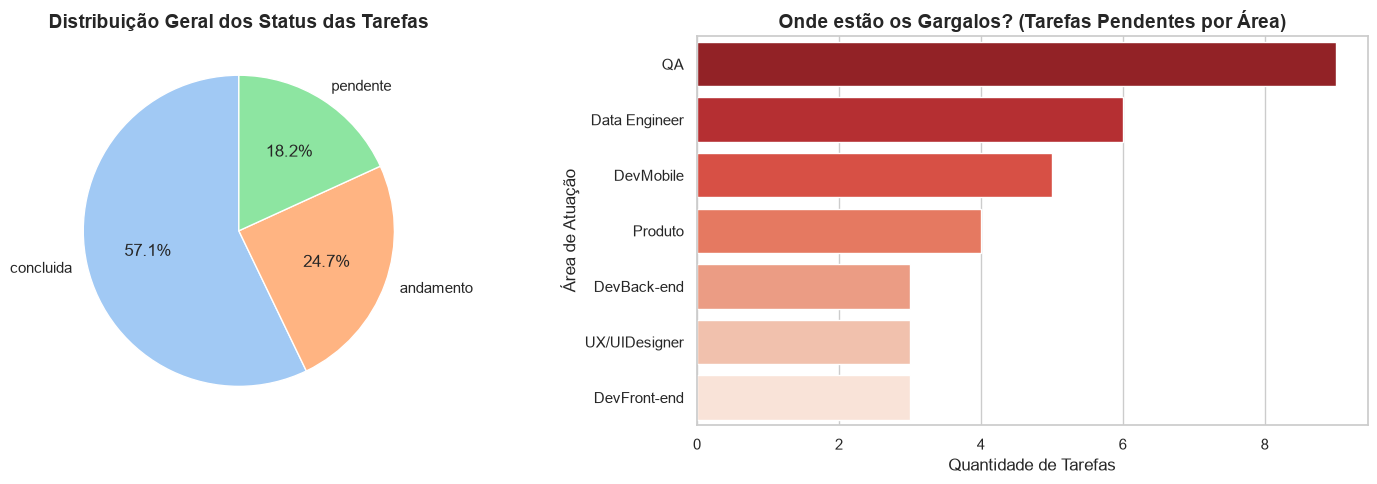

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

# Gráfico 1: Distribuição de Status
plt.subplot(1, 2, 1)
status_cores = sns.color_palette("pastel")[0:3]
plt.pie(status_qtd, labels=status_qtd.index, autopct='%1.1f%%', startangle=90, colors=status_cores)
plt.title("Distribuição Geral dos Status das Tarefas", fontsize=14, fontweight='bold')

# Gráfico 2: Tarefas Pendentes por Área
plt.subplot(1, 2, 2)
sns.barplot(x=pendentes_por_area.values, y=pendentes_por_area.index, palette="danger_r" if "danger_r" in dir(sns.color_palette) else "Reds_r")
plt.title("Onde estão os Gargalos? (Tarefas Pendentes por Área)", fontsize=14, fontweight='bold')
plt.xlabel("Quantidade de Tarefas")
plt.ylabel("Área de Atuação")

plt.tight_layout()
plt.show()